<a href="https://colab.research.google.com/github/so-alive/NLP-sentiment-classification/blob/main/sentiment_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# helps load dataset
from datasets import load_dataset

# load dataset

https://huggingface.co/datasets/dair-ai/emotion


In [3]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
label_names = emotion_dataset['train'].features['label'].names

In [5]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

In [6]:
df_train.isnull().sum()

,0
text,0
label,0


# exploratory data analysis

<Axes: xlabel='label', ylabel='count'>

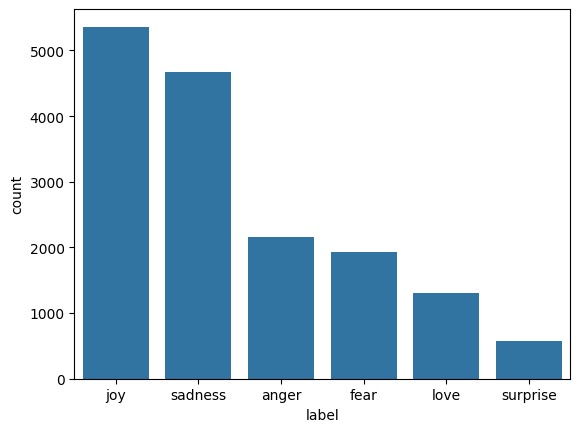

In [8]:
sns.countplot(x = 'label', data = df_train, order = df_train['label'].value_counts().index)

# Data processing - NLP

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token = '<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding = 'post', truncating = 'post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating = 'post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)


num_classes = len(np.unique(train_labels))

print(f"Vocablury Size: {len(tokenizer.word_index)}")
print(f"Meax Sentence Length: {padded_train_sequence.shape[1]}")

Vocablury Size: 15213
Meax Sentence Length: 50


# shared training utilities

In [23]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)
class_weight_dict= dict(enumerate(class_weights))

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = '3',
    restore_best_weights=True
)